In [1]:
#### Requirment
# Pandas
# Matplotlib
# Seaborn
# Scikit-learn
# BM_NLP_Classification_WP
# Pickle
# streamlit

# 1. Import the libraries

In [2]:
# Basic libraries
import re
import pandas as pd
import numpy as np

# For plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

import BM_NLP_Classification_WP

import importlib
importlib.reload(BM_NLP_Classification_WP)

import pickle


# 2. Load the dataset

In [3]:
# First read attempt
DF = pd.read_csv("twitter_training.csv")

In [4]:
# Preview the first rows to confirm the header problem
DF.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [5]:
# Read again with header=None and give the four columns proper names
DF = pd.read_csv("twitter_training.csv",
                 header=None,
                 names=["ID", "Entity", "Sentiment", "Text"])

# This is a multiclass NLP text-classification problem.

In [6]:
# Number of rows and columns in the dataset
DF.shape

(74682, 4)

In [7]:
# Column names, non-null counts and data types
DF.info()

<class 'pandas.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         74682 non-null  int64
 1   Entity     74682 non-null  str  
 2   Sentiment  74682 non-null  str  
 3   Text       73996 non-null  str  
dtypes: int64(1), str(3)
memory usage: 11.4 MB


In [8]:
# Count the missing values in each column
DF.isna().sum()

ID             0
Entity         0
Sentiment      0
Text         686
dtype: int64

In [9]:
# Count how many rows are exact duplicates
DF.duplicated().sum()

np.int64(2700)

In [10]:
# Work on a copy so the original DataFrame stays untouched
df = DF.copy()

# 3. Explore the data (EDA)

In [11]:
# To find out many tweets of each sentiment do we have
print(df["Sentiment"].value_counts())
print()
print("In percentage:")
print(df["Sentiment"].value_counts(normalize=True).round(3) * 100)

Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

In percentage:
Sentiment
Negative      30.2
Positive      27.9
Neutral       24.5
Irrelevant    17.4
Name: proportion, dtype: float64


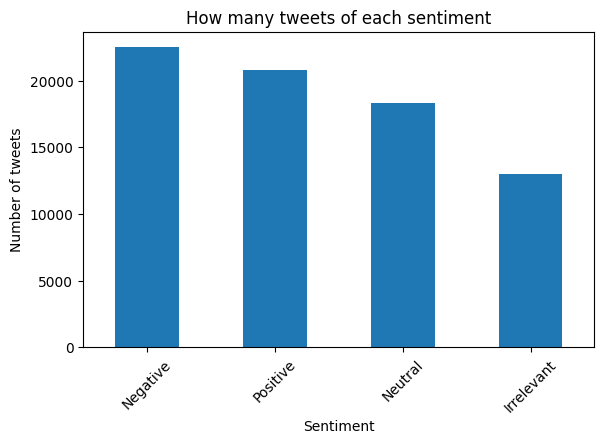

In [12]:
# Bar plot of the sentiment
df["Sentiment"].value_counts().plot(kind="bar")

plt.title("How many tweets of each sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of tweets")
plt.xticks(rotation=45)

plt.tight_layout(pad=2.0)
plt.show()